#### Image and Numpy Basics

In this section we will discuss image basics applying Numpy arrays to images

---

How does a computer represent image data?
 - Each image can be represented as an array.
 - Ex. a number is presented by pixels (such as 28 $\times$ 28 gray scale).
 - More resolution (more pixels)



---

Numpy can't open directly jpeg file so we need to use PIL <b> (Python Imaging Library )</b>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

## Binary Image

The simplest kind of images are binary images, which can have two values typically black and white or 0 and 1. Because only one binary digit is required to represent each pixel, a binary image is referred to as a 1-bit image.

A threshold operation, in which every pixel above the threshold value is made white ('1') and those below it are made black ('0'), is frequently used to create binary images from grayscale images.

In [42]:
img_binary = np.random.choice([0, 1], size=(5, 5)).astype(np.uint8)

In [43]:
img_binary

array([[1, 1, 1, 0, 1],
       [0, 1, 0, 0, 1],
       [1, 0, 0, 1, 0],
       [1, 1, 1, 1, 0],
       [1, 0, 0, 1, 1]], dtype=uint8)

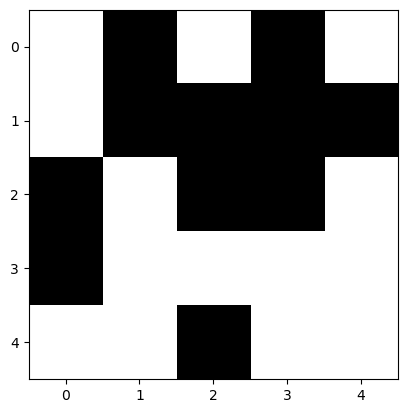

In [21]:
plt.imshow(img_binary,cmap='gray')

In cases of 2d array, matplotlib function <i>imshow<i> need a colormap value to plot the image. By default it does not takes 0- Black and 1- White. In default cases it takes 0- purple and 1- yellow.

## Grey Scale Image(One Color Channel)

Gray-scale images are referred to as monochrome (one-color) images in the figure below. The number of available gray levels is determined by the number of bits used for each pixel.

Generally Represented using two formats:
8 bit format and 16 bit format 

8 bit Format

In [40]:
img_8bit = np.random.randint(0, 256, size=(5, 5), dtype=np.uint8)

In [41]:
img_8bit

array([[ 24,  40, 104,  54, 221],
       [112, 190,   2,  77, 104],
       [210,  80, 179, 150, 247],
       [ 36, 237, 236,  26,  75],
       [244, 165,  76, 255,  88]], dtype=uint8)

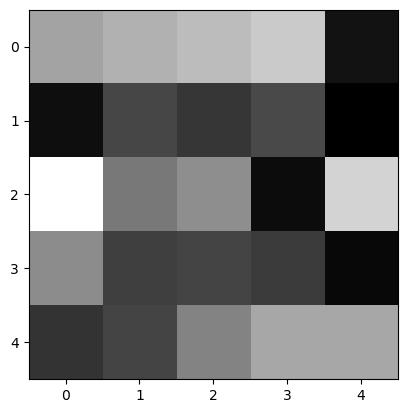

In [12]:
plt.imshow(img_8bit,cmap='gray')

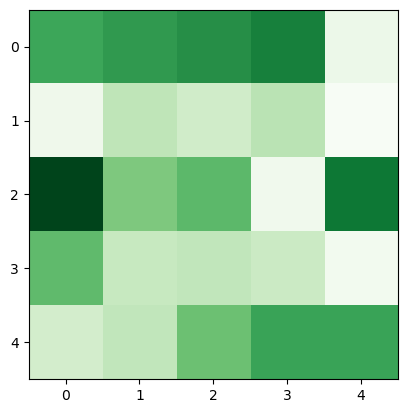

In [13]:
plt.imshow(img_8bit,cmap='Greens')
# Here, cmap='Greens' maps the pixel values to different shades of green.

16 bit Colour Format

In [14]:
img_16bit = np.random.randint(0, 65536, size=(5, 5), dtype=np.uint16)

In [15]:
img_16bit

array([[27656, 56363, 39290,   610,  7785],
       [ 7220, 54461, 43690, 45664, 51297],
       [61181, 56823,   879, 52157, 35789],
       [14513,   949, 47792, 29403, 51181],
       [24808, 45989, 29616, 14985, 12624]], dtype=uint16)

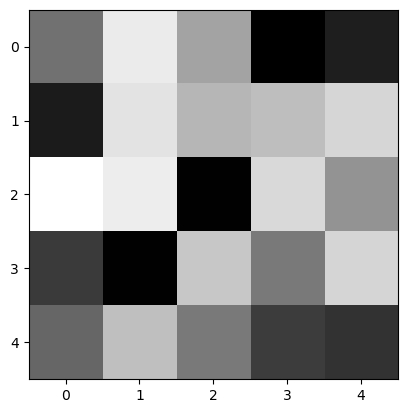

In [16]:
plt.imshow(img_16bit,cmap='gray')

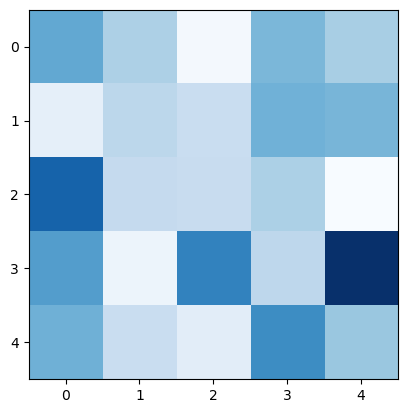

In [ ]:
plt.imshow(img_16bit,cmap='Blues')

Now for all above images have a shape of 5*5 i.e. Height * Weight.
And have olny one color channel.
But a Real life Image have generally three channels i.e. Red, Green, Blue
These three combines to give us different colours.

Color images:

Color images can be represented as three-band monochrome image data, with each band representing a distinct color. The gray-level information for each spectral band is the actual data that is kept in the digital image data. 
 - Color images can be represented as a combination of Red, Green and Blue (RGB) that allows to create different range of colors.
 - Each color channel will have intensity values.
 - In python, shape of color array has 3 diimensions <b>(Height, Width, Color Channels)</b>
 - Example - (1270,720,3): 3D array , one for each color
  - pixel width = 1270
  - pixel height = 720
  - color channels = 3

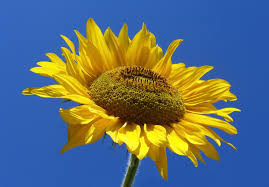

In [25]:
pic = Image.open('C:\\Users\\dixit\\Downloads\\images.jpg')
pic

In [26]:
type(pic)

PIL.JpegImagePlugin.JpegImageFile

In [27]:
pic_arr = np.asarray(pic)
type(pic_arr)

numpy.ndarray

In [28]:
pic_arr.shape

(187, 269, 3)

In [29]:
pic_arr[0][0]

array([ 54, 104, 189], dtype=uint8)

Now Here, the pixel’s color is formed by combining medium red intensity (95), medium green intensity (81), and medium blue intensity (78).

In [30]:
pic_arr[0][1]

array([ 54, 104, 189], dtype=uint8)

(-0.5, 268.5, 186.5, -0.5)

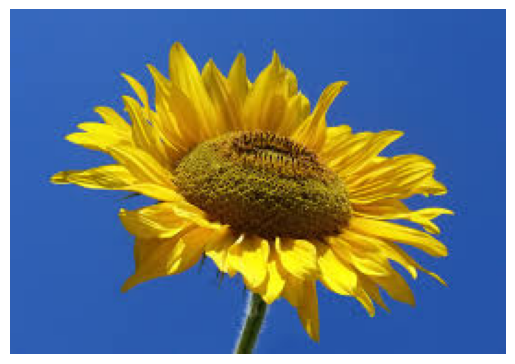

In [44]:
plt.imshow(pic_arr)
plt.axis('off')

In [47]:
pic_red = pic_arr.copy()
pic_green = pic_arr.copy()
pic_blue = pic_arr.copy()

pic_red[:,:,0]

array([[54, 54, 54, ..., 40, 40, 40],
       [54, 54, 54, ..., 40, 40, 40],
       [54, 54, 54, ..., 40, 40, 40],
       ...,
       [47, 47, 46, ..., 38, 38, 37],
       [47, 47, 46, ..., 38, 38, 37],
       [47, 47, 46, ..., 38, 38, 37]], dtype=uint8)

It returns the red channel of the image as a 2D array, where each element represents the intensity of red color at that pixel location.

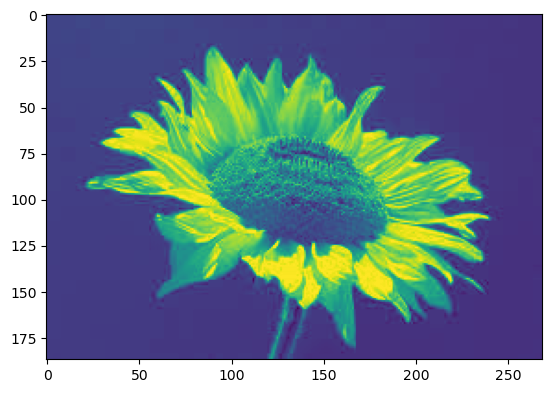

In [48]:
plt.imshow(pic_red[:,:,0])

Though, we are displaying the red channel of the pic, we don't see red colour variation is bcz, array pic_red[:,:,0] is treated as just a 2d array containing some intensity values(0-255) and imshow fn uses cmap= virdus by default.

When a 3d array is passed to imshow fn, it doesn't need a cmap now and colours are represented using intensity va.lue of each colour channel present.

By default the colour channels are considered to be RGB in PIL.

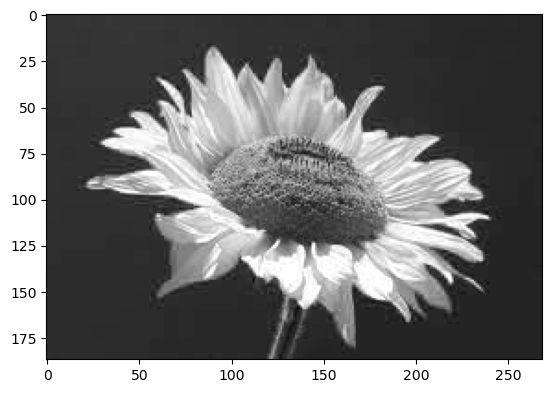

In [49]:
plt.imshow(pic_red[:,:,0],cmap='gray')

And now the colour map is changed to Grayscale

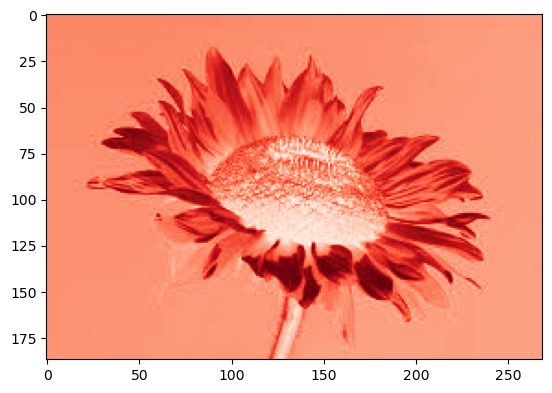

In [51]:
plt.imshow(pic_red[:,:,1],cmap='Reds')

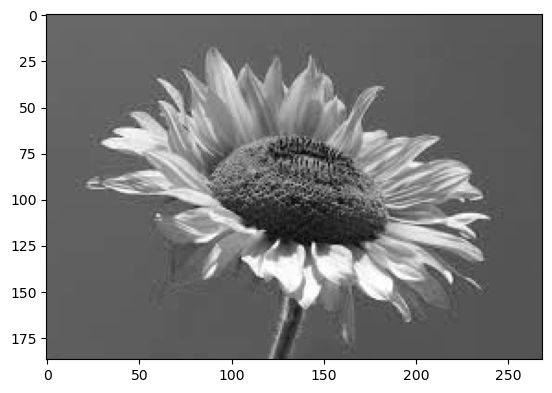

In [52]:
plt.imshow(pic_red[:,:,1],cmap='gray')

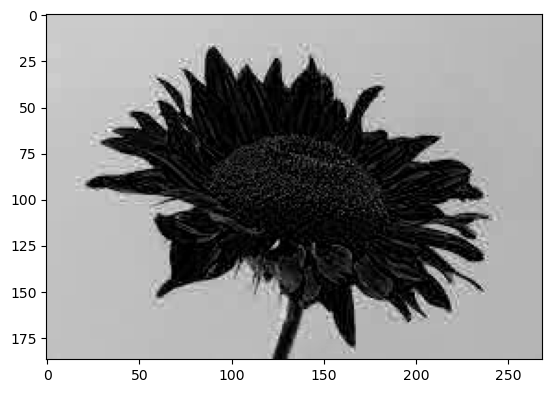

In [53]:
plt.imshow(pic_red[:,:,2],cmap='gray')

Now in above two images, you can see a difference in the intensity of the pixels, its because the Green Channel has greater intensity values than Blue channel. As seen in cell no 17 and 18.

In [54]:
# To see the red channel pic, we have to zero out the green and blue channels.
pic_red[:,:,1]=0 #green channel is zero
pic_red[:,:,2]=0 # blue channel is zero

In [55]:
pic_red

array([[[54,  0,  0],
        [54,  0,  0],
        [54,  0,  0],
        ...,
        [40,  0,  0],
        [40,  0,  0],
        [40,  0,  0]],

       [[54,  0,  0],
        [54,  0,  0],
        [54,  0,  0],
        ...,
        [40,  0,  0],
        [40,  0,  0],
        [40,  0,  0]],

       [[54,  0,  0],
        [54,  0,  0],
        [54,  0,  0],
        ...,
        [40,  0,  0],
        [40,  0,  0],
        [40,  0,  0]],

       ...,

       [[47,  0,  0],
        [47,  0,  0],
        [46,  0,  0],
        ...,
        [38,  0,  0],
        [38,  0,  0],
        [37,  0,  0]],

       [[47,  0,  0],
        [47,  0,  0],
        [46,  0,  0],
        ...,
        [38,  0,  0],
        [38,  0,  0],
        [37,  0,  0]],

       [[47,  0,  0],
        [47,  0,  0],
        [46,  0,  0],
        ...,
        [38,  0,  0],
        [38,  0,  0],
        [37,  0,  0]]], dtype=uint8)

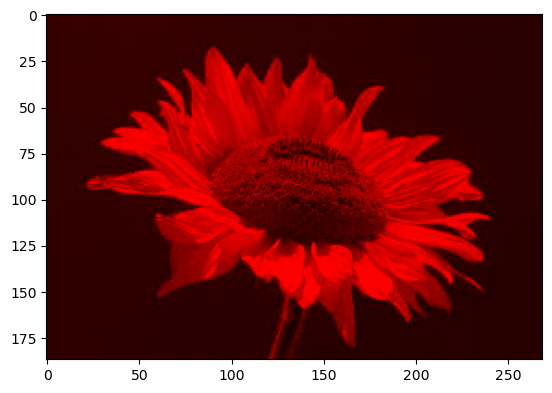

In [56]:
plt.imshow(pic_red)

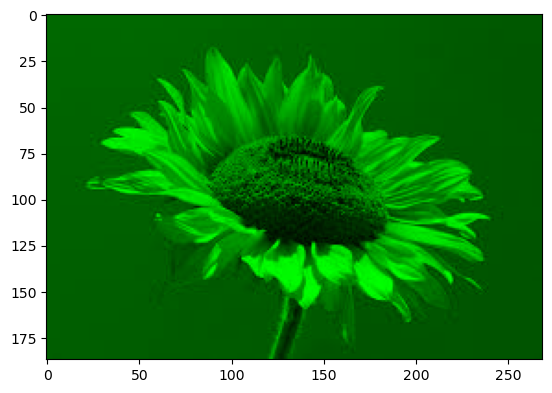

In [57]:
pic_green[:,:,0]=0 # red channel is zero
pic_green[:,:,2]=0 # blue channel is zero
plt.imshow(pic_green)

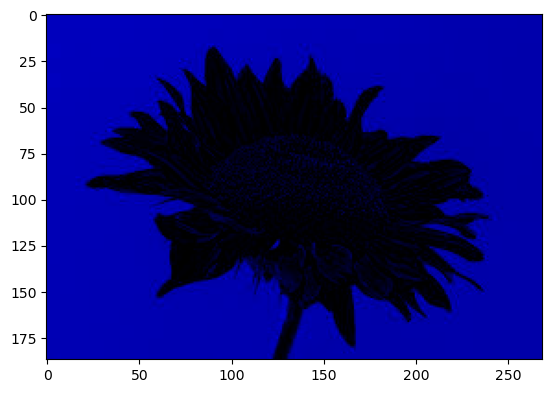

In [58]:
pic_blue[:,:,0]=0 # red channel is zero
pic_blue[:,:,1]=0 # green channel is zero
plt.imshow(pic_blue)